In [1]:
import warnings
warnings.filterwarnings('ignore',category=RuntimeWarning)
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import glob,os,sys
from tqdm.auto import tqdm
import proplot as plot
import json,pickle
import dask.array as da
import gc
from tools import derive_var,read_and_proc,preproc_noensemble
from tools.mlr import mlr
from tools.preprocess import do_eof,preproc_maria,preproc_haiyan
from tqdm.auto import tqdm
sys.path.insert(1, '../')
import read_stuff as read
import torch
from torch.utils.data import DataLoader, TensorDataset
import vae3d
from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss
import optuna
import torch.nn.functional as F
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import math
import data_process
import random
import preproc_decomp
plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',
                'tick.labelweight':'ultralight','gridminor.linestyle':'--','title.weight':'normal','linewidth':0.5})
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32"

/tmp/ipykernel_1574061/2301260017.py:33: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({'figure.facecolor':'w','axes.labelweight':'ultralight',


In [2]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 11.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 10,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/tmp/ipykernel_1574061/4003527188.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [3]:
device = 'cpu'
folds = data_process.setup_folds(n_numbers=20,indepedent_test={10,17},val_size=4,seed=42)
lassoalpha=0.1
num_rad=5

Fold 1: validation members = [4, 9, 13, 14]
Fold 2: validation members = [5, 6, 7, 18]
Fold 3: validation members = [1, 11, 12, 16]
Fold 4: validation members = [2, 8, 15, 19]
Fold 5: validation members = [0, 3, 13, 14]


In [4]:
import pandas as pd

def get_complexities(TYPE='test',metric='MAE',lassoalpha=0.1):
    complexities = []
    num_rads = []
    num_verts = []
    for num_rad in [2,3,4,5,6,7,8,9,10]:
        results = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{num_rad}_performance.pkl')
        tempdict = {num_rad+numv: np.asarray([d[metric] for d in results[TYPE][num_rad][numv]]).mean() for numv in [2,3,4,5,6,7,8,9,10]}
        num_rads = [num_rad for _ in [2,3,4,5,6,7,8,9,10]]
        num_verts = [numv for numv in [2,3,4,5,6,7,8,9,10]]
        complexities.append(pd.DataFrame({'featurenum':list(tempdict.keys()),'metric':list(tempdict.values()),'numrad':num_rads,'numvert':num_verts}))
    return complexities

def is_pareto_efficient(costs):
    """
    Returns a boolean array indicating whether each point is Pareto efficient.
    'costs' is an (n_points, n_costs) array, where lower values are better.
    """
    is_efficient = np.ones(costs.shape[0], dtype=bool)
    for i, c in enumerate(costs):
        if is_efficient[i]:
            # Remove dominated points
            is_efficient[is_efficient] = np.any(costs[is_efficient] < c, axis=1) | np.all(costs[is_efficient] == c, axis=1)
            is_efficient[i] = True  # keep self
    return is_efficient

def calculate_optimal_destandardized_coefficients(
    Y_target, beta_weights_std, intercept_std, mean_vector, std_dev_vector
):
    """
    Calculates the optimal, unstandardized coefficient vector C_req_flat
    for reconstruction, given a target outcome Y_target, assuming the 
    input X was standardized.

    Parameters
    ----------
    Y_target : float
        The desired fixed outcome value.
    beta_weights_std : ndarray
        The optimal weight vector (model.coef_) from the standardized Lasso model (β_std).
    intercept_std : float
        The intercept (model.intercept_) from the standardized Lasso model (β_0,std).
    mean_vector : ndarray
        The mean of each feature/coefficient column in the original X (μ).
    std_dev_vector : ndarray
        The standard deviation of each feature/coefficient column in the original X (σ).

    Returns
    -------
    C_req_flat : ndarray
        The unstandardized coefficient vector (C_flat) ready for reconstruction.
    """
    
    # 1. Calculate the scaling factor (k)
    beta_norm_sq = np.sum(beta_weights_std**2)
    
    if np.abs(beta_norm_sq) < 1e-12:
        return mean_vector # If no weights, the best guess is the mean field
        
    k = (Y_target - intercept_std) / beta_norm_sq
    
    # 2. Calculate the required input in standardized space (X_std, req)
    X_std_req = k * beta_weights_std
    
    # 3. DE-STANDARDIZATION: Convert back to the physical coefficient space
    # C_req_flat = X_std_req * sigma + mu
    C_req_flat = X_std_req * std_dev_vector + mean_vector
    
    return C_req_flat

In [5]:
complexities_valid = pd.concat(get_complexities('valid','MAE',0.1)).reset_index()
# Apply to your data
costs = complexities_valid[['featurenum', 'metric']].values
pareto_mask = is_pareto_efficient(costs)

pareto_df = complexities_valid[pareto_mask]

In [102]:
# Obtain the best model
model_numrad, model_numvert = pareto_df['numrad'].iloc[4], pareto_df['numvert'].iloc[4]
models = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{model_numrad}_performance.pkl')['model'][model_numrad][model_numvert]
meanstd_coeffs = read_and_proc.depickle(f'./newproc/directC/lasso_alpha0.1_nr{model_numrad}_performance.pkl')['meanstd_coeffs'][model_numrad][model_numvert]

In [103]:
y_target = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{model_numrad}_performance.pkl')['y'][model_numrad][model_numvert][0]['test'].squeeze().max()

In [104]:
model_numrad, model_numvert

(7, 2)

## Reconstruct A0 field

In [105]:
from preproc_decomp import radial_modes, reconstruct_field, vertical_modes_pressure

In [106]:
def calculate_optimal_destandardized_coefficients(
    Y_target, beta_weights_std, intercept_std, mean_vector, std_dev_vector
):
    """
    Calculates the optimal, unstandardized coefficient vector C_req_flat
    for reconstruction, given a target outcome Y_target, assuming the 
    input X was standardized.

    Parameters
    ----------
    Y_target : float
        The desired fixed outcome value.
    beta_weights_std : ndarray
        The optimal weight vector (model.coef_) from the standardized Lasso model (β_std).
    intercept_std : float
        The intercept (model.intercept_) from the standardized Lasso model (β_0,std).
    mean_vector : ndarray
        The mean of each feature/coefficient column in the original X (μ).
    std_dev_vector : ndarray
        The standard deviation of each feature/coefficient column in the original X (σ).

    Returns
    -------
    C_req_flat : ndarray
        The unstandardized coefficient vector (C_flat) ready for reconstruction.
    """
    
    # 1. Calculate the scaling factor (k)
    beta_norm_sq = np.sum(beta_weights_std**2)
    
    if np.abs(beta_norm_sq) < 1e-12:
        return mean_vector # If no weights, the best guess is the mean field
        
    k = (Y_target - intercept_std) / beta_norm_sq
    
    # 2. Calculate the required input in standardized space (X_std, req)
    X_std_req = k * beta_weights_std
    
    # 3. DE-STANDARDIZATION: Convert back to the physical coefficient space
    # C_req_flat = X_std_req * sigma + mu
    C_req_flat = X_std_req * std_dev_vector + mean_vector
    
    return C_req_flat
    
def reconstruct_optimal_volume_A0(
    C_opt_A0, r, p, Psi_all, nmax, jmax, a, bc_r
):
    """
    Reconstructs the optimal 2D axisymmetric (m=0) field Q_opt(r, p)
    from its spectral coefficients C_opt_A0.

    Parameters
    ----------
    C_opt_A0 : ndarray (nmax, jmax)
        Optimal coefficients for the m=0 component.
    r : ndarray
        Radial grid coordinates.
    p : ndarray
        Vertical (pressure) grid coordinates.
    Psi_all : ndarray (Np, jmax)
        The full vertical basis array (ψ_j(p)).
    nmax : int
        Number of radial modes.
    jmax : int
        Number of vertical modes.
    a : float
        Outer radius (r.max()).
    bc_r : str
        Radial boundary condition ("dirichlet" or "neumann").

    Returns
    -------
    Q_opt_field : ndarray (Nr, Np)
        The reconstructed optimal axisymmetric field Q(r, p).
    """
    
    # Helper to get the radial basis for m=0
    def get_radial_basis(r, nmax, a, bc):
        """Retrieves the radial basis Phi_0 for the m=0 component."""
        # Use m=0 for J_0 Bessel function
        Phi_m0, _, _ = radial_modes(r, a=a, m=0, nmax=nmax, bc=bc) 
        return Phi_m0

    # 1. Retrieve the m=0 (axisymmetric) radial basis
    Phi_m0 = get_radial_basis(r, nmax, a, bc_r)
    
    # 2. Reconstruct the (Nr, Np) field using the inverse projection
    # Q(r, p) = sum_n sum_j C_nj * Phi_n(r) * Psi_j(p)
    Q_opt_field = reconstruct_field(C_opt_A0, Phi_m0, Psi_all)
    
    # Output shape is (Nr, Np)
    return Q_opt_field

def get_optimal_a0(model_numrad,model_numvert,r_grid,p_grid,bc_vert,bc_radial,y_target,models,meanstd_coeffs):
    # # --- Setup (Must be consistent with decomposition) ---
    nmax_used = model_numrad     # Radial modes count
    jmax_used = model_numvert     # Vertical modes count
    a_radius = r_grid.max()

    # # Assume Psi_all is loaded/calculated (Np, jmax)
    Psi_all, _, _ = vertical_modes_pressure(p_grid, jmax=jmax_used, bc=bc_vert)
    # # Assume C_opt_A0 (nmax, jmax) is the final output from your Lasso analysis
    C_opt_A0s, opt_A0_fields = [],[]
    for i in range(len(models)):
        C_opt_A0 = calculate_optimal_destandardized_coefficients(y_target, models[i].coef_, models[i].intercept_,
                                                       meanstd_coeffs['mu_wv0'][i].squeeze().flatten(),
                                                       meanstd_coeffs['sigma_wv0'][i].squeeze().flatten()).reshape(nmax_used, jmax_used) # Placeholder
        # # --- Run the Reconstruction ---
        # # optimal_A0_field is Q_opt(r, p)
        optimal_A0_field = reconstruct_optimal_volume_A0(
            C_opt_A0, r_grid, p_grid, Psi_all, 
            nmax_used, jmax_used, a_radius, bc_radial
        )

        C_opt_A0s.append(C_opt_A0)
        opt_A0_fields.append(optimal_A0_field)
    return C_opt_A0s, opt_A0_fields

In [108]:
# # --- Setup (Must be consistent with decomposition) ---
r_grid = np.linspace(0,207,208)*3 # km
p_grid = np.linspace(1000,100,10) # Vertical grid
bc_vert = 'neumann'
bc_radial = 'neumann'

y_target = read_and_proc.depickle(f'./newproc/directC/lasso_alpha{lassoalpha}_nr{model_numrad}_performance.pkl')['y'][model_numrad][model_numvert][0]['train'].squeeze().max()

In [109]:
C_opt_A0s, opt_A0_fields = get_optimal_a0(model_numrad,model_numvert,r_grid,p_grid,bc_vert,bc_radial,y_target,models,meanstd_coeffs)

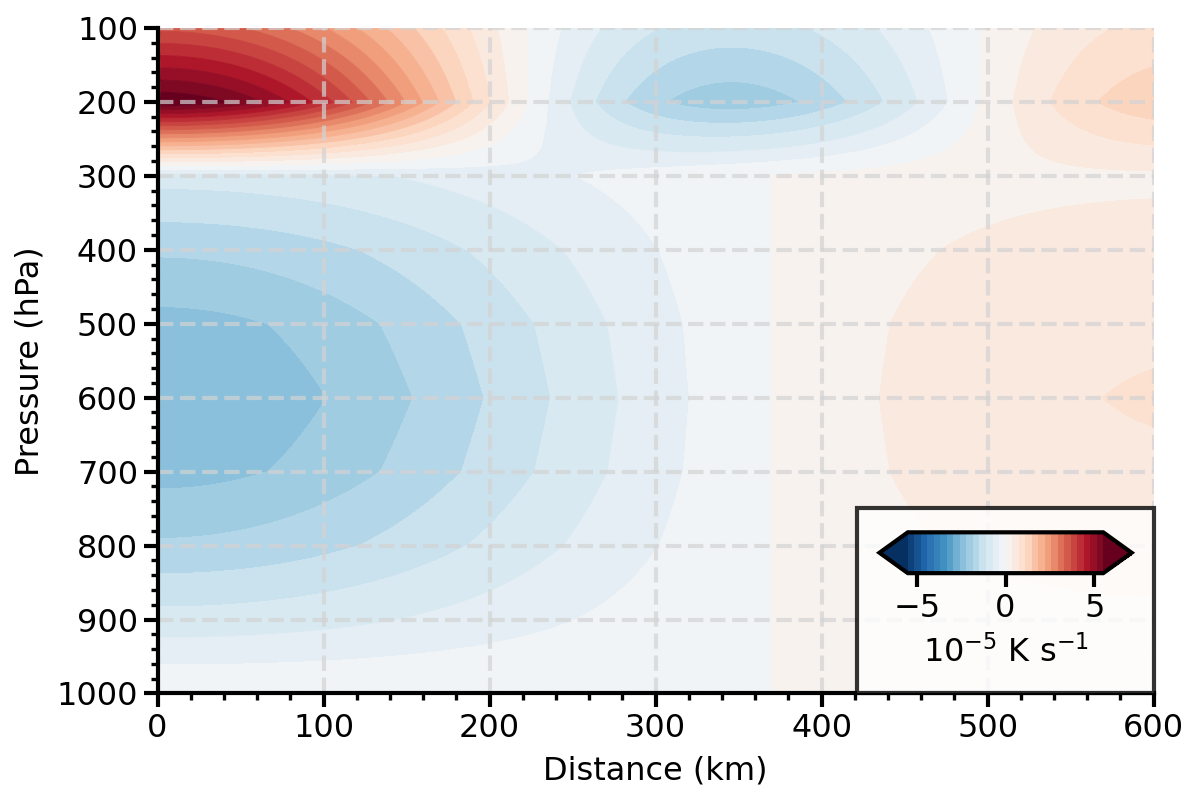

In [81]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(r_grid, p_grid, np.array(opt_A0_fields).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
#plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()

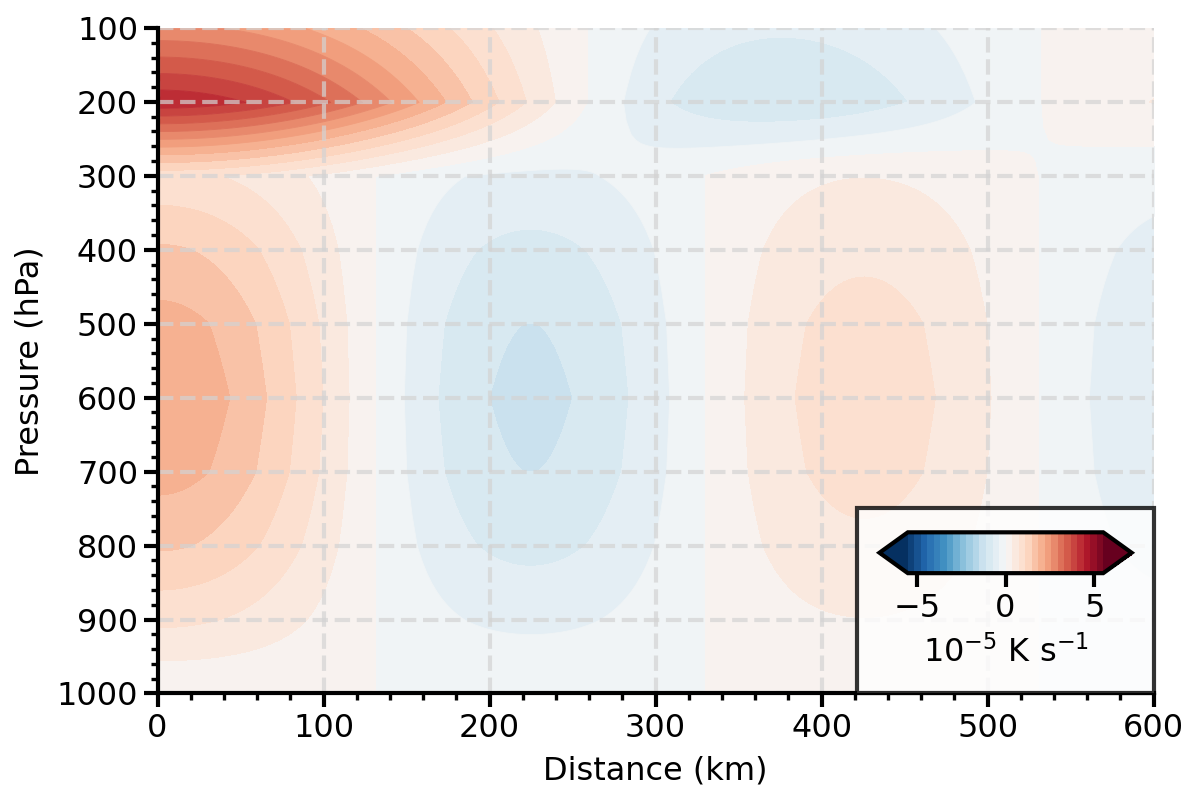

In [63]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(r_grid, p_grid, np.array(opt_A0_fields).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
#plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()

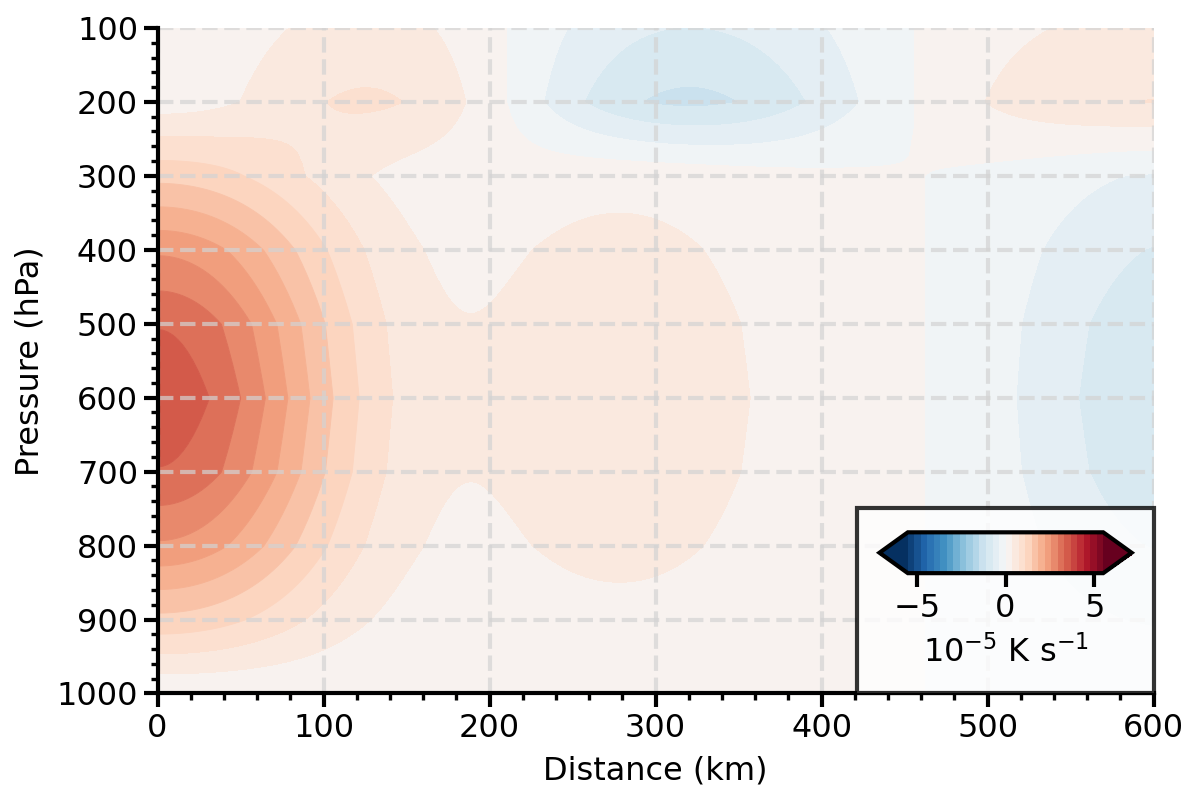

In [72]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(r_grid, p_grid, np.array(opt_A0_fields).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
#plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()

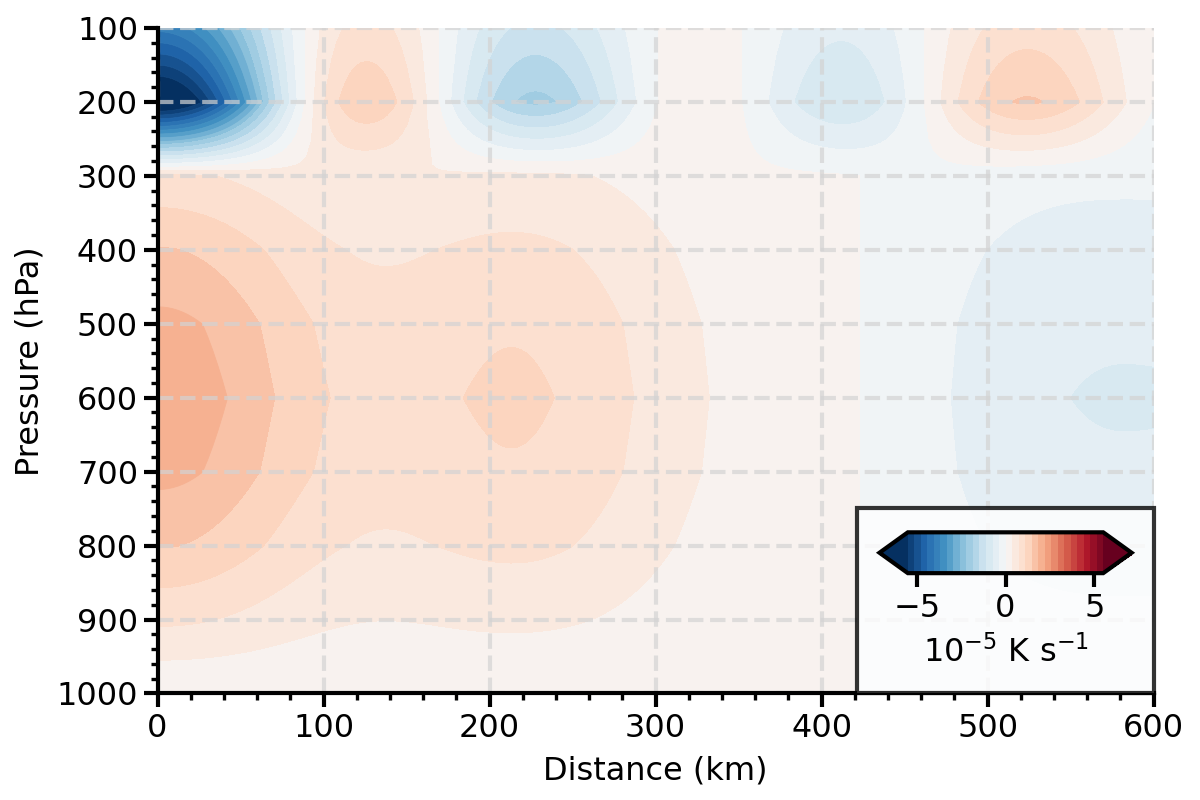

In [92]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(r_grid, p_grid, np.array(opt_A0_fields).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
#plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()

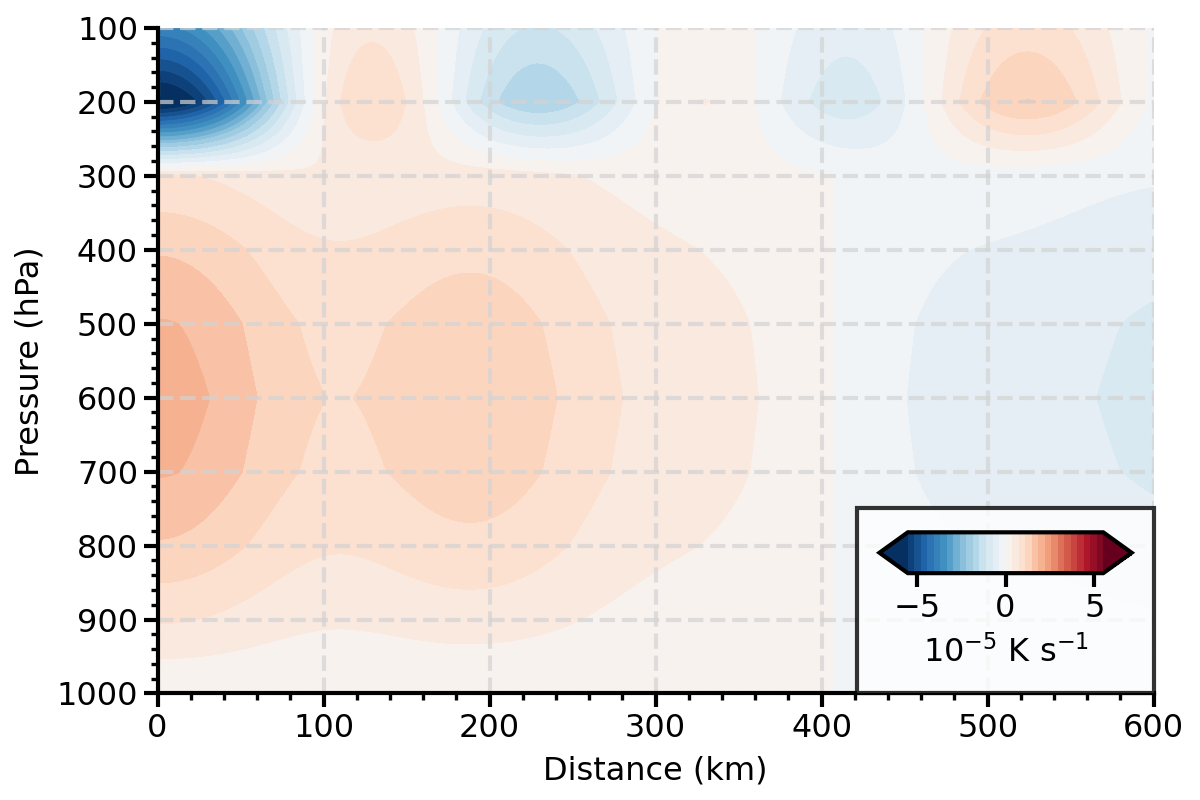

In [110]:
fig, axs = plot.subplots(ncols=1,nrows=1, figsize=(6,4), share=False)
pzv = axs.contourf(r_grid, p_grid, np.array(opt_A0_fields).mean(axis=0).transpose()*10**5,levels=np.linspace(-5.5,5.5,31),extend='both',cmap='RdBu_r')
axs.format(xlim=(0,600),ylim=(1000,100),
           xlabel='Distance (km)', ylabel='Pressure (hPa)')
axs.colorbar(pzv,ax=axs,loc='lower right',ticks=[-5,0,5],label='10$^{-5}$ K s$^{-1}$')
#plt.savefig('./haiyan_sen/pics/2day_CRFavg.png',dpi=400)
plt.show()